In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from ipywidgets import interact, IntSlider
import ipywidgets as widgets
from IPython.display import display

from resources.cut_off_black_segments import cut_off_black_segments

In [2]:
PROJECT_DIR = Path(r"C:\Users\abram\PycharmProjects\DrivenData_DAT_Parkinsons")
NIFTI_DIR = PROJECT_DIR / "data" / "niftis"
FILE_NAME = "0ezzf8s2.nii.gz"
FILE_PATH = NIFTI_DIR / FILE_NAME

In [3]:
original_img = nib.load(FILE_PATH)
original = original_img.get_fdata(dtype=np.float32)

cropped, _ = cut_off_black_segments(
    path=FILE_PATH,
    threshold=3,
    margin=1,
)

print("Plik:", FILE_PATH.name)
print("Oryginalny shape:", original.shape)
print("Shape po wycięciu:", cropped.shape)

Plik: 0ezzf8s2.nii.gz
Oryginalny shape: (128, 128, 128)
Shape po wycięciu: (116, 114, 106)


In [4]:
def middle_slices(volume: np.ndarray) -> tuple[np.ndarray, ...]:
    x_mid = volume.shape[0] // 2
    y_mid = volume.shape[1] // 2
    z_mid = volume.shape[2] // 2

    return (
        volume[x_mid, :, :],
        volume[:, y_mid, :],
        volume[:, :, z_mid],
    )

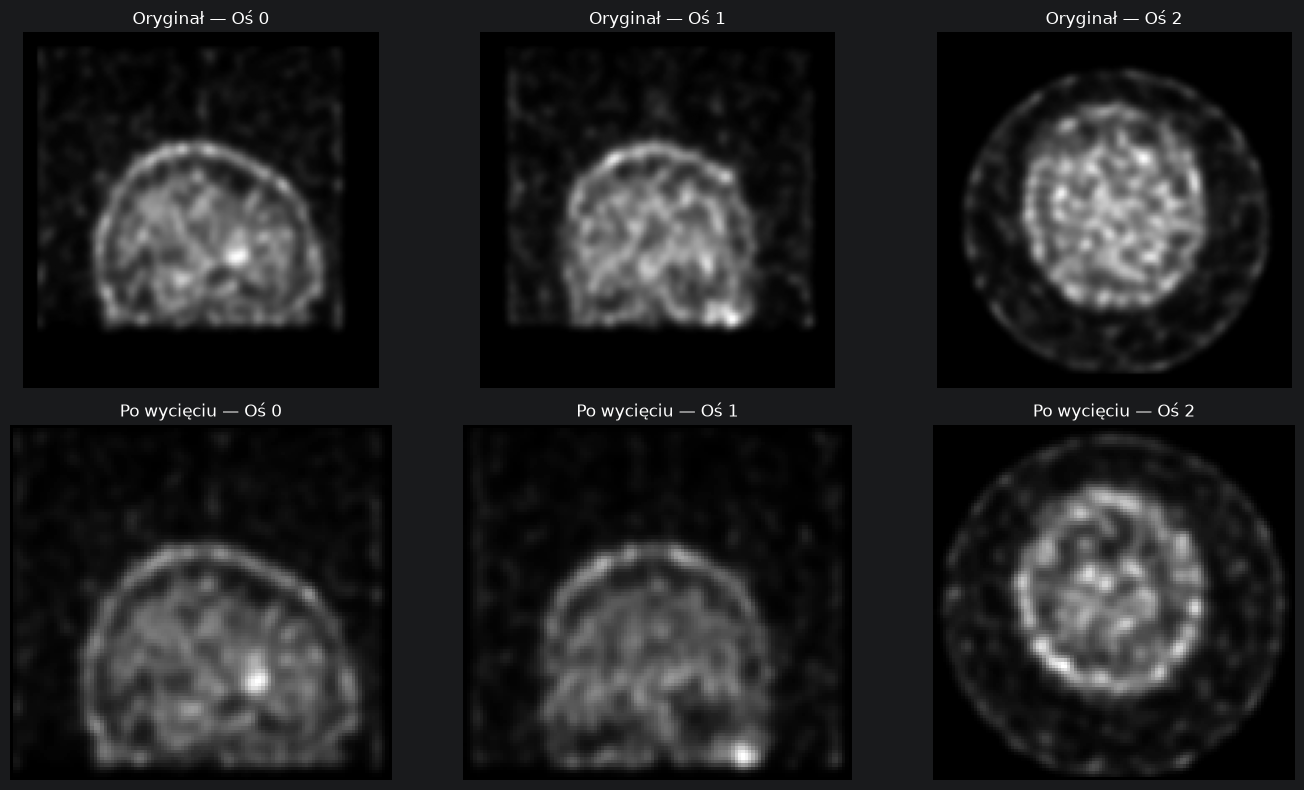

In [5]:
original_slices = middle_slices(original)
cropped_slices = middle_slices(cropped)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
titles = [
    "Oś 0",
    "Oś 1",
    "Oś 2",
]

for axis, image, title in zip(axes[0], original_slices, titles):
    axis.imshow(image.T, cmap="gray", origin="lower")
    axis.set_title(f"Oryginał — {title}")
    axis.axis("off")

for axis, image, title in zip(axes[1], cropped_slices, titles):
    axis.imshow(image.T, cmap="gray", origin="lower")
    axis.set_title(f"Po wycięciu — {title}")
    axis.axis("off")

plt.tight_layout()
plt.show()

In [6]:
original_x_slider = widgets.IntSlider(
    value=original.shape[0] // 2,
    min=0,
    max=original.shape[0] - 1,
    step=1,
    description="Oryg. oś 0:",
    continuous_update=False
)

original_y_slider = widgets.IntSlider(
    value=original.shape[1] // 2,
    min=0,
    max=original.shape[1] - 1,
    step=1,
    description="Oryg. oś 1:",
    continuous_update=False
)

original_z_slider = widgets.IntSlider(
    value=original.shape[2] // 2,
    min=0,
    max=original.shape[2] - 1,
    step=1,
    description="Oryg. oś 2:",
    continuous_update=False
)

cropped_x_slider = widgets.IntSlider(
    value=cropped.shape[0] // 2,
    min=0,
    max=cropped.shape[0] - 1,
    step=1,
    description="Crop oś 0:",
    continuous_update=False
)

cropped_y_slider = widgets.IntSlider(
    value=cropped.shape[1] // 2,
    min=0,
    max=cropped.shape[1] - 1,
    step=1,
    description="Crop oś 1:",
    continuous_update=False
)

cropped_z_slider = widgets.IntSlider(
    value=cropped.shape[2] // 2,
    min=0,
    max=cropped.shape[2] - 1,
    step=1,
    description="Crop oś 2:",
    continuous_update=False
)


def show_slices(
        original_x,
        original_y,
        original_z,
        cropped_x,
        cropped_y,
        cropped_z
):
    original_indices = [original_x, original_y, original_z]
    cropped_indices = [cropped_x, cropped_y, cropped_z]

    original_slices = [
        original[original_x, :, :],
        original[:, original_y, :],
        original[:, :, original_z]
    ]

    cropped_slices = [
        cropped[cropped_x, :, :],
        cropped[:, cropped_y, :],
        cropped[:, :, cropped_z]
    ]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    titles = ["Oś 0", "Oś 1", "Oś 2"]

    for i, (axis, image, title) in enumerate(
            zip(axes[0], original_slices, titles)
    ):
        axis.imshow(image.T, cmap="gray", origin="lower")
        axis.set_title(
            f"Oryginał — {title}\n"
            f"slice {original_indices[i]}/{original.shape[i] - 1}"
        )
        axis.axis("off")

    for i, (axis, image, title) in enumerate(
            zip(axes[1], cropped_slices, titles)
    ):
        axis.imshow(image.T, cmap="gray", origin="lower")
        axis.set_title(
            f"Po wycięciu — {title}\n"
            f"slice {cropped_indices[i]}/{cropped.shape[i] - 1}"
        )
        axis.axis("off")

    plt.tight_layout()
    plt.show()


controls = widgets.VBox([
    widgets.HBox([
        original_x_slider,
        original_y_slider,
        original_z_slider
    ]),
    widgets.HBox([
        cropped_x_slider,
        cropped_y_slider,
        cropped_z_slider
    ])
])

output = widgets.interactive_output(
    show_slices,
    {
        "original_x": original_x_slider,
        "original_y": original_y_slider,
        "original_z": original_z_slider,
        "cropped_x": cropped_x_slider,
        "cropped_y": cropped_y_slider,
        "cropped_z": cropped_z_slider
    }
)

display(controls, output)


Output()